In [20]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


In [21]:
# @title
caminho = r'C:\Users\Diego\Downloads\DatasetColunaVertebral.csv'
df = pd.read_csv(caminho)
print(df.to_string())

     pelvic incidence   pelvic tilt   lumbar lordosis angle   sacral slope   pelvic radius   grade of spondylolisthesis Class_att
0           63.027817     22.552586               39.609117      40.475232       98.672917                    -0.254400  Abnormal
1           39.056951     10.060991               25.015378      28.995960      114.405425                     4.564259  Abnormal
2           68.832021     22.218482               50.092194      46.613539      105.985135                    -3.530317  Abnormal
3           69.297008     24.652878               44.311238      44.644130      101.868495                    11.211523  Abnormal
4           49.712859      9.652075               28.317406      40.060784      108.168725                     7.918501  Abnormal
5           40.250200     13.921907               25.124950      26.328293      130.327871                     2.230652  Abnormal
6           53.432928     15.864336               37.165934      37.568592      120.567523

In [22]:
# @title
num_registros = len(df)
print(f"Número de registros: {num_registros}")
total_duplicatas = df.duplicated().sum()
print(f"Total de linhas duplicadas: {total_duplicatas}")
print("\nContagem de dados nulos por coluna:")
print(df.isnull().sum())

Número de registros: 310
Total de linhas duplicadas: 0

Contagem de dados nulos por coluna:
pelvic incidence               0
 pelvic tilt                   0
 lumbar lordosis angle         0
 sacral slope                  0
 pelvic radius                 0
 grade of spondylolisthesis    0
Class_att                      0
dtype: int64


In [23]:
# @title
# PRÉ-PROCESSAMENTO DE DADOS
# Eliminado o excesso de casas após a virgula
df.iloc[:, :6] = df.iloc[:, :6].round(2)
# Substituição do Abnormal por Anormal
df['Class_att'] = df['Class_att'].replace('Abnormal', 'Anormal')

df_tratados = df
print(df_tratados.to_string())

     pelvic incidence   pelvic tilt   lumbar lordosis angle   sacral slope   pelvic radius   grade of spondylolisthesis Class_att
0               63.03         22.55                   39.61          40.48           98.67                        -0.25   Anormal
1               39.06         10.06                   25.02          29.00          114.41                         4.56   Anormal
2               68.83         22.22                   50.09          46.61          105.99                        -3.53   Anormal
3               69.30         24.65                   44.31          44.64          101.87                        11.21   Anormal
4               49.71          9.65                   28.32          40.06          108.17                         7.92   Anormal
5               40.25         13.92                   25.12          26.33          130.33                         2.23   Anormal
6               53.43         15.86                   37.17          37.57          120.57

In [24]:
# @title
print('ANALISE EXPLORATORIO DO CONJUNTO COLUNA VERTEBRAL')
print('Valores exploratorios segundo Artigo "Incidência Pélvica: um parâmetro fundamental para definição do equilíbrio sagital da coluna vertebral" e "Classificação de Meyerding"')
print(f"Total de registros: {len(df_tratados)} pacientes")
total = len(df_tratados)
classificacaoAnormal = round((len(df_tratados[df_tratados['Class_att'] == 'Anormal']) / total)* 100, 2)
classificacaoNormal = round((len(df_tratados[df_tratados['Class_att'] == 'Normal']) / total)* 100, 2)
IP_Anormal = round((len(df_tratados[(df_tratados['pelvic incidence'] < 40) | (df_tratados['pelvic incidence'] > 65)])/total)*100, 2)
IP_Normal = round((len(df_tratados[(df_tratados['pelvic incidence'] >= 40) & (df_tratados['pelvic incidence'] <= 65)])/total)*100, 2)
VP_Anormal = round((len(df_tratados[(df_tratados[' pelvic tilt'] < 10) | (df_tratados[' pelvic tilt'] > 25)])/total)*100,2)
VP_Normal = round((len(df_tratados[(df_tratados[' pelvic tilt'] >= 10) & (df_tratados[' pelvic tilt'] <= 25)])/total)*100, 2)
LL_Anormal = round((len(df_tratados[(df_tratados[' lumbar lordosis angle'] < 40) | (df_tratados[' lumbar lordosis angle'] > 80)])/total)*100, 2)
LL_Normal = round((len(df_tratados[(df_tratados[' lumbar lordosis angle'] >= 40) & (df_tratados[' lumbar lordosis angle'] <= 80)])/total)*100, 2)
IS_Anormal = round((len(df_tratados[(df_tratados[' sacral slope'] < 30) | (df_tratados[' sacral slope'] > 50)])/total)*100, 2)
IS_Normal = round((len(df_tratados[(df_tratados[' sacral slope'] >= 30) & (df_tratados[' sacral slope'] <= 50)])/total)*100, 2)
RP_Anormal = round((len(df_tratados[(df_tratados[' pelvic radius'] < 83.7)])/total)*100, 2)
RP_Indefinido = round((len(df_tratados[(df_tratados[' pelvic radius'] > 83.7) & (df_tratados[' pelvic radius'] < 92.9)])/total)*100, 2)
RP_Normal = round((len(df_tratados[(df_tratados[' pelvic radius'] >= 92.9)])/total)*100, 2)

print(f"Total de pacientes classificados: {classificacaoAnormal}% anormais e {classificacaoNormal}% normais")
print(f"Incidência Pélvica:               {IP_Anormal}% anormais (<40° ou >65°) e {IP_Normal}% normais (40-65°)")
print(f"Versão Pélvica:                   {VP_Anormal}% anormais (<10° ou >25°) e {VP_Normal}% normais (10-25°)")
print(f"Lordose Lombar:                   {LL_Anormal}% anormais (<40° ou >80°) e {LL_Normal}% normais (40-80°)")
print(f"Inclinação Sacral:                {IS_Anormal}% anormais (<30° ou >50°) e {IS_Normal}% normais (40-80°)")
print(f"Raio Pélvico:                     {RP_Anormal}% anormais (<83.7°), {RP_Indefinido}% indefinidos (83.7 - 92.9°) e {RP_Normal}% normais (>92.9°)")

# Função para classificar o grau de Meyerding
def classificar_meyerding(percentual):
    if percentual <= 0:
        return 'Grau 0 (normal)'
    elif percentual <= 25:
        return 'Grau I (1-25%)'
    elif percentual <= 50:
        return 'Grau II (26-50%)'
    elif percentual <= 75:
        return 'Grau III (51-75%)'
    elif percentual <= 100:
        return 'Grau IV (76-100%)'
    else:
        return 'Grau V (>100%)'

# Aplicar a classificação
df['Meyerding'] = df_tratados[' grade of spondylolisthesis'].apply(classificar_meyerding)

# Calcular porcentagens
total = len(df_tratados)
contagem = df['Meyerding'].value_counts()
porcentagens = (contagem / total) * 100

# Exibir resultados

print("Grau de Espondilolistese:")

ordem_graus = ['Grau 0 (normal)', 'Grau I (1-25%)', 'Grau II (26-50%)',
               'Grau III (51-75%)', 'Grau IV (76-100%)', 'Grau V (>100%)']

dados_graus = {
    "Grau": [],
    "Registros": [],
    "Percentual (%)": []
}

for grau in ordem_graus:
    qtd = contagem.get(grau, 0)
    pct = (qtd / total) * 100
    dados_graus["Grau"].append(grau)
    dados_graus["Registros"].append(qtd)
    dados_graus["Percentual (%)"].append(round(pct, 2))
    print(f"{grau}: {qtd} paciente(s) ({pct:.1f}%)")

# Normalização de dados

def is_anormal_pelvic_incidence(x):
    return (x < 40) | (x > 65)

def is_anormal_pelvic_tilt(x):
    return (x < 10) | (x > 25)

def is_anormal_lumbar_lordosis(x):
    return (x < 40) | (x > 60)

def is_anormal_sacral_slope(x):
    return (x < 30) | (x > 50)

def is_anormal_pelvic_radius(x):
    return x < 83.7

def is_anormal_grade(x):
    return x > 0

criterios = {
    'pelvic incidence': is_anormal_pelvic_incidence,
    ' pelvic tilt': is_anormal_pelvic_tilt,
    ' lumbar lordosis angle': is_anormal_lumbar_lordosis,
    ' sacral slope': is_anormal_sacral_slope,
    ' pelvic radius': is_anormal_pelvic_radius,
    ' grade of spondylolisthesis': is_anormal_grade
}

df_normalizado = pd.DataFrame(index=df_tratados.index)

for col, func in criterios.items():
  anormal = func(df[col])
  df_normalizado[col] = anormal.astype(int)

colunas_criterios = list(criterios.keys())
df_normalizado['total_anormalidade'] = df_normalizado[colunas_criterios].sum(axis=1)

freq_abs = df_normalizado['total_anormalidade'].value_counts().sort_index()
freq_rel = freq_abs / len(df_normalizado) * 100

resumo = pd.DataFrame({
    'Nº de anormalidades': freq_abs.index,
    'Frequência (registros)': freq_abs.values,
    'Porcentagem (%)': freq_rel.values
})

resumo['Porcentagem (%)'] = resumo['Porcentagem (%)'].round(2)

print("Distribuição das anormalidades (todos os pacientes)")
print(resumo.to_string(index=False))

ANALISE EXPLORATORIO DO CONJUNTO COLUNA VERTEBRAL
Valores exploratorios segundo Artigo "Incidência Pélvica: um parâmetro fundamental para definição do equilíbrio sagital da coluna vertebral" e "Classificação de Meyerding"
Total de registros: 310 pacientes
Total de pacientes classificados: 67.74% anormais e 32.26% normais
Incidência Pélvica:               49.35% anormais (<40° ou >65°) e 50.65% normais (40-65°)
Versão Pélvica:                   40.0% anormais (<10° ou >25°) e 60.0% normais (10-25°)
Lordose Lombar:                   37.1% anormais (<40° ou >80°) e 62.9% normais (40-80°)
Inclinação Sacral:                45.16% anormais (<30° ou >50°) e 54.84% normais (40-80°)
Raio Pélvico:                     1.29% anormais (<83.7°), 2.26% indefinidos (83.7 - 92.9°) e 96.45% normais (>92.9°)
Grau de Espondilolistese:
Grau 0 (normal): 58 paciente(s) (18.7%)
Grau I (1-25%): 116 paciente(s) (37.4%)
Grau II (26-50%): 68 paciente(s) (21.9%)
Grau III (51-75%): 46 paciente(s) (14.8%)
Grau IV (7

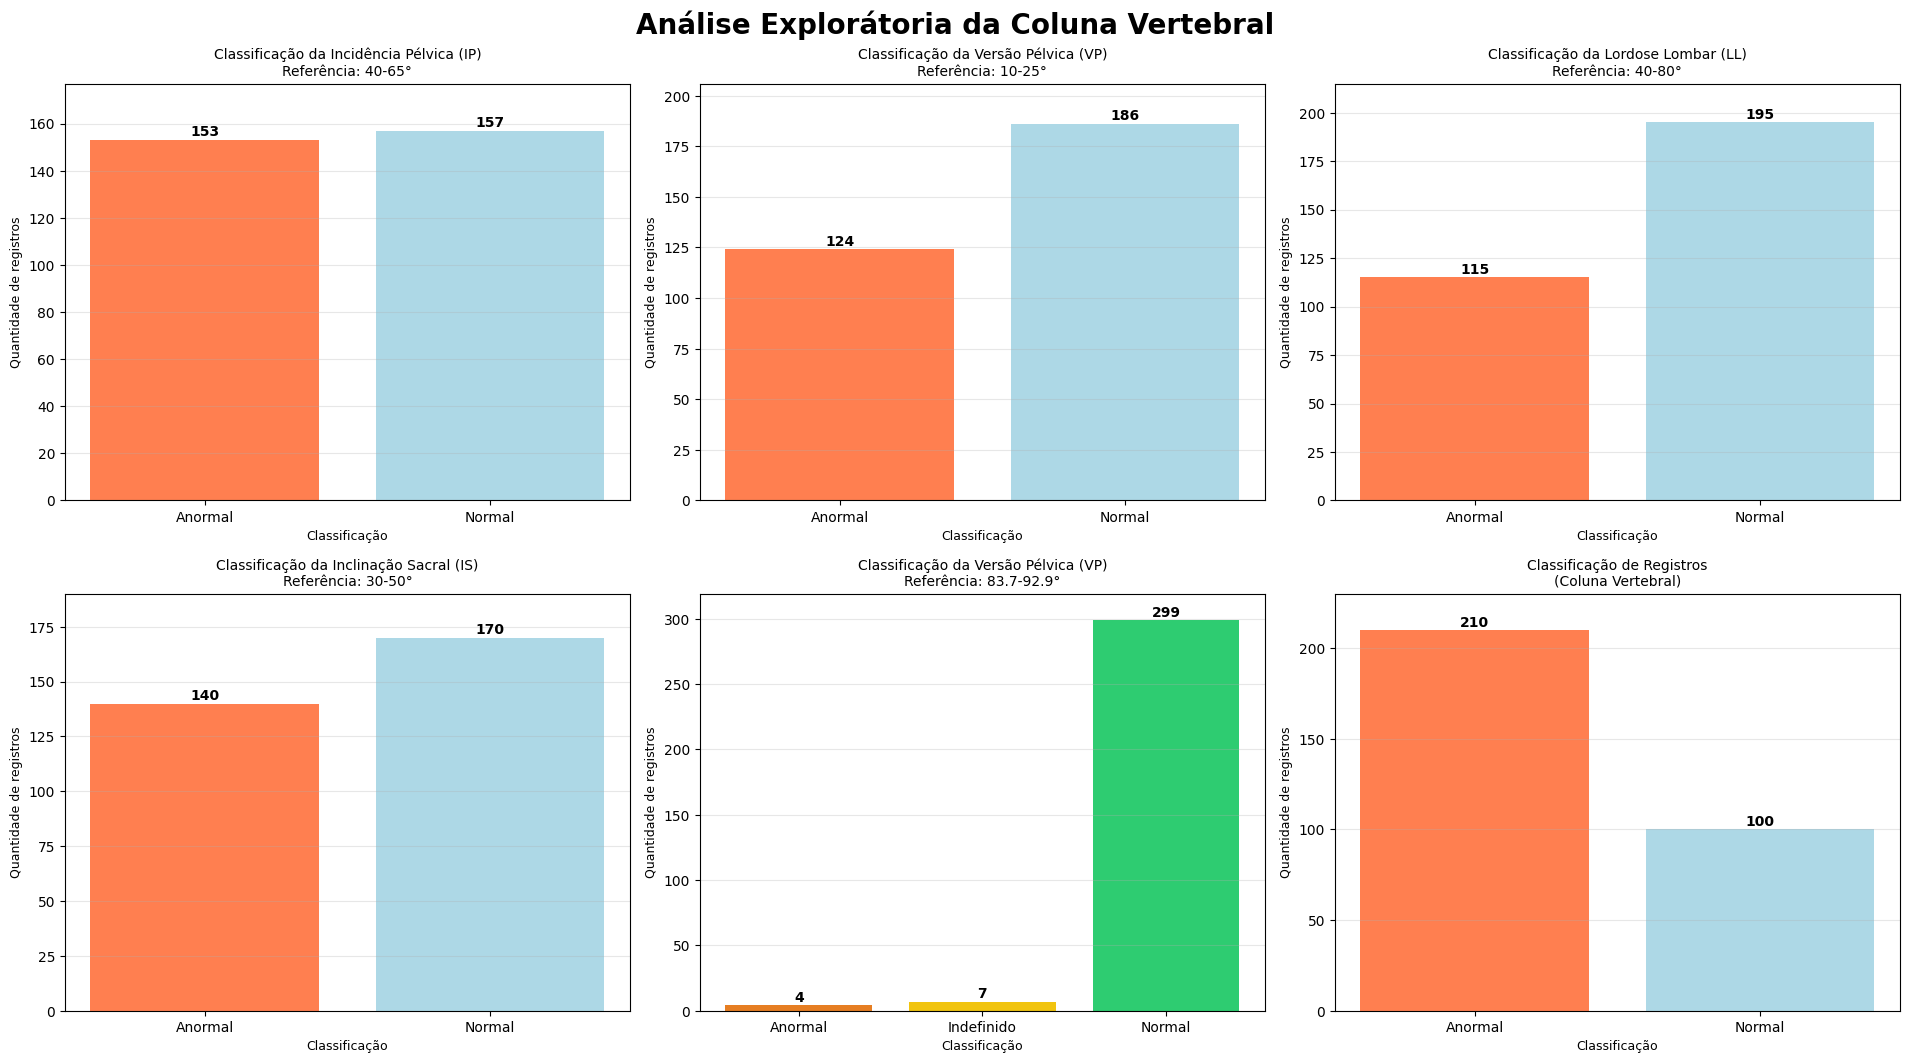

In [25]:
# @title

fig, axes = plt.subplots(2, 3, figsize=(1920/100, 1080/100))

fig.suptitle('Análise Explorátoria da Coluna Vertebral',
             fontsize=20, fontweight='bold', y=0.98)

ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[0, 2]
ax4 = axes[1, 0]
ax5 = axes[1, 1]
ax6 = axes[1, 2]

# GRÁFICO 1: Incidência Pélvica
df_tratados['Classificacao_IP'] = df_tratados['pelvic incidence'].apply(
    lambda ip: 'Normal' if 40 <= ip <= 65 else 'Anormal'
)

contagem_ip = df_tratados['Classificacao_IP'].value_counts().reindex(['Anormal', 'Normal'])
cores1 = ['coral', 'lightblue']
ax1.bar(['Anormal', 'Normal'], contagem_ip, color=cores1)
ax1.set_title("Classificação da Incidência Pélvica (IP)\nReferência: 40-65°", fontsize=10)
ax1.set_xlabel("Classificação", fontsize=9)
ax1.set_ylabel("Quantidade de registros", fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(contagem_ip) + 20)
for i, v in enumerate(contagem_ip):
    ax1.text(i, v + 0.5, f'{v}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# GRÁFICO 2: Versão Pélvica
df_tratados['Classificacao_VP'] = df_tratados[' pelvic tilt'].apply(
    lambda ip: 'Normal' if 10 <= ip <= 25 else 'Anormal'
)

contagem_ip = df_tratados['Classificacao_VP'].value_counts().reindex(['Anormal', 'Normal'])
cores2 = ['coral', 'lightblue']
ax2.bar(['Anormal', 'Normal'], contagem_ip, color=cores2)
ax2.set_title("Classificação da Versão Pélvica (VP)\nReferência: 10-25°", fontsize=10)
ax2.set_xlabel("Classificação", fontsize=9)
ax2.set_ylabel("Quantidade de registros", fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(contagem_ip) + 20)
for i, v in enumerate(contagem_ip):
    ax2.text(i, v + 0.5, f'{v}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# GRÁFICO 3: Lordose Lombar
df_tratados['Classificacao_LL'] = df_tratados[' lumbar lordosis angle'].apply(
    lambda ip: 'Normal' if 40 <= ip <= 80 else 'Anormal'
)

contagem_ip = df_tratados['Classificacao_LL'].value_counts().reindex(['Anormal', 'Normal'])
cores3 = ['coral', 'lightblue']
ax3.bar(['Anormal', 'Normal'], contagem_ip, color=cores3)
ax3.set_title("Classificação da Lordose Lombar (LL)\nReferência: 40-80°", fontsize=10)
ax3.set_xlabel("Classificação", fontsize=9)
ax3.set_ylabel("Quantidade de registros", fontsize=9)
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, max(contagem_ip) + 20)
for i, v in enumerate(contagem_ip):
    ax3.text(i, v + 0.5, f'{v}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# GRÁFICO 4: Inclinação Sacral
df_tratados['Classificacao_IS'] = df_tratados[' sacral slope'].apply(
    lambda ip: 'Normal' if 30 <= ip <= 50 else 'Anormal'
)

contagem_ip = df_tratados['Classificacao_IS'].value_counts().reindex(['Anormal', 'Normal'])
cores4 = ['coral', 'lightblue']
ax4.bar(['Anormal', 'Normal'], contagem_ip, color=cores3)
ax4.set_title("Classificação da Inclinação Sacral (IS)\nReferência: 30-50°", fontsize=10)
ax4.set_xlabel("Classificação", fontsize=9)
ax4.set_ylabel("Quantidade de registros", fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, max(contagem_ip) + 20)
for i, v in enumerate(contagem_ip):
    ax4.text(i, v + 0.5, f'{v}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# GRÁFICO 5: Raio Pélvico
df_tratados['Classificacao_RP'] = df_tratados[' pelvic radius'].apply(
    lambda pr: 'Anormal' if pr < 83.7 else ('Normal' if pr >= 92.9 else 'Indefinido')
)

contagem_ip = df_tratados['Classificacao_RP'].value_counts().reindex(['Anormal', 'Indefinido', 'Normal'])
cores5 = ['#e67e22', '#f1c40f','#2ecc71']
ax5.bar(['Anormal', 'Indefinido','Normal'], contagem_ip, color=cores5)
ax5.set_title("Classificação da Versão Pélvica (VP)\nReferência: 83.7-92.9°", fontsize=10)
ax5.set_xlabel("Classificação", fontsize=9)
ax5.set_ylabel("Quantidade de registros", fontsize=9)
ax5.grid(axis='y', alpha=0.3)
ax5.set_ylim(0, max(contagem_ip) + 20)
for i, v in enumerate(contagem_ip):
    ax5.text(i, v + 0.5, f'{v}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# GRÁFICO 6: Classificação dos registros
contagem_att = df_tratados['Class_att'].value_counts().reindex(['Anormal', 'Normal'])
cores6 = ['coral', 'lightblue']
ax6.bar(['Anormal', 'Normal'], contagem_att, color=cores6)
ax6.set_title("Classificação de Registros\n(Coluna Vertebral)", fontsize=10)
ax6.set_xlabel("Classificação", fontsize=9)
ax6.set_ylabel("Quantidade de registros", fontsize=9)
ax6.grid(axis='y', alpha=0.3)
ax6.set_ylim(0, max(contagem_att) + 20)
for i, v in enumerate(contagem_att):
    ax6.text(i, v + 0.5, f'{v}', ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.tight_layout()
plt.show()

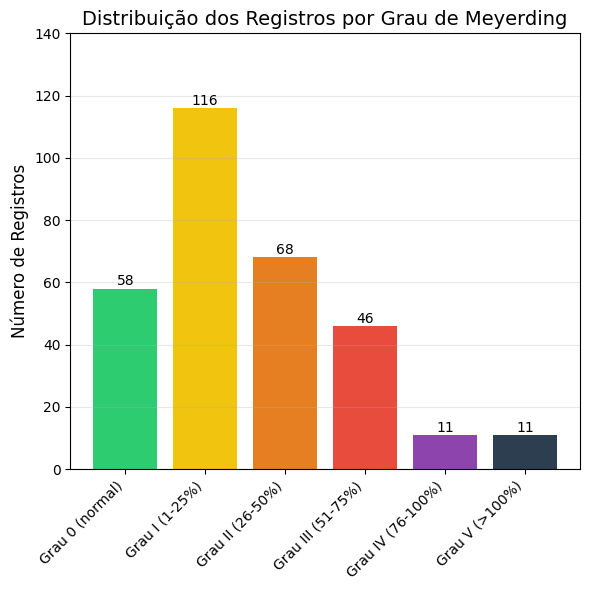

In [26]:
# @title
total = len(df_tratados)
ordem_graus = ['Grau 0 (normal)', 'Grau I (1-25%)', 'Grau II (26-50%)',
               'Grau III (51-75%)', 'Grau IV (76-100%)', 'Grau V (>100%)']
valores = [df_tratados['Meyerding'].value_counts().get(grau, 0) for grau in ordem_graus]

cores = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad', '#2c3e50']

plt.figure(figsize=(6, 6))
barras = plt.bar(ordem_graus, valores, color=cores)

plt.ylabel('Número de Registros', fontsize=12)
plt.title('Distribuição dos Registros por Grau de Meyerding', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0,140)
for barra, valor in zip(barras, valores):
    pct = (valor / total) * 100
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.1,
             f'{valor}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [27]:
# @title

# Cabeçalho principal
display(Markdown("# 📊 Análise Exploratória - Coluna Vertebral"))
display(Markdown("**Referências:** *Incidência Pélvica: um parâmetro fundamental para definição do equilíbrio sagital da coluna vertebral* e *Classificação de Meyerding*"))
display(Markdown(f"**Total de registros:** `{len(df_tratados)}` registros"))

# Cards com métricas gerais
display(Markdown("## 📈 Visão Geral"))
html_cards = f"""
<div style="display: flex; gap: 20px; margin-bottom: 20px; justify-content: center;">
    <div style="background-color: #f8f9fa; padding: 15px; border-radius: 10px; box-shadow: 2px 2px 5px rgba(0,0,0,0.1); text-align: center; flex:1; max-width: 300px;">
        <h3>✅ Normais</h3>
        <p style="font-size: 32px; color: green;">{(classificacaoNormal):.2f}%</p>
        <p>({int(len(df_tratados)*((classificacaoNormal)/100))} registros)</p>
    </div>
    <div style="background-color: #f8f9fa; padding: 15px; border-radius: 10px; box-shadow: 2px 2px 5px rgba(0,0,0,0.1); text-align: center; flex:1; max-width: 300px;">
        <h3>⚠️ Anormais</h3>
        <p style="font-size: 32px; color: red;">{(classificacaoAnormal):.2f}%</p>
        <p>({int(len(df_tratados)*((classificacaoAnormal)/100))} registros)</p>
    </div>
</div>
"""
display(HTML(html_cards))

# ESTILO GLOBAL PARA TODAS AS TABELAS
estilo_tabelas = '''
<style>
    .tabela-centralizada {
        display: flex;
        justify-content: center;
        margin: 20px 0;
        width: 100%;
    }
    .tabela-centralizada table {
        border-collapse: collapse;
        width: auto;
        min-width: 80%;
        box-shadow: 2px 2px 5px rgba(0,0,0,0.05);
    }
    .tabela-centralizada th, .tabela-centralizada td {
        padding: 10px 15px;
        border: 1px solid #ddd;
        text-align: center;
    }
    .tabela-centralizada th {
        background-color: #f2f2f2;
        font-weight: bold;
    }
    .tabela-centralizada td:first-child {
        text-align: left;
    }
</style>
'''
display(HTML(estilo_tabelas))

# Tabela de critérios individuais (com barra visual)
display(Markdown("## 🦴 Critérios Radiológicos"))

dados_criterios = {
    "Critério": ["Incidência Pélvica", "Versão Pélvica", "Lordose Lombar", "Inclinação Sacral"],
    "Anormais (%)": [IP_Anormal, VP_Anormal, LL_Anormal, IS_Anormal],
    "Normais (%)": [IP_Normal, VP_Normal, LL_Normal, IS_Normal],
    "Faixa normal": ["40-65°", "10-25°", "40-80°", "30-50°"]
}
df_crit = pd.DataFrame(dados_criterios)

def barra(pct, width=20):
    filled = int(width * pct / 100)
    bar = (f'<span style="color: #ff4444;">{"█" * filled}</span>'
           f'<span style="color: #4CAF50;">{"█" * (width - filled)}</span>')
    return f"{bar} {pct:.1f}%"

df_crit["Distribuição"] = df_crit["Anormais (%)"].apply(barra)

df_crit["Anormais (%)"] = df_crit["Anormais (%)"].apply(lambda x: f"{x:.2f}")
df_crit["Normais (%)"] = df_crit["Normais (%)"].apply(lambda x: f"{x:.2f}")

html_tabela3 = df_crit.to_html(escape=False, index=False)
display(HTML(f'<div class="tabela-centralizada">{html_tabela3}</div>'))

dados_raio = {
    "Distribuição": ["Anormal", "Indefinido", "Normal"],
    "Faixas": ["< 83.7","83.7 - 92.9", "92.9 >"],
    "Quantidade de Registros": [int(total*(RP_Anormal/100)), int(total*(RP_Indefinido/100)), int(total*(RP_Normal/100))],
    "Percentual (%)": [RP_Anormal, RP_Indefinido, RP_Normal]
}
df_crit = pd.DataFrame(dados_raio)
html_tabela4 = df_crit.to_html(escape=False, index=False)
display(HTML(f'<div class="tabela-centralizada">{html_tabela4}</div>'))

# Grau de Espondilolistese (tabela colorida)
display(Markdown("## 🩻 Grau de Espondilolistese (Classificação de Meyerding)"))

df_graus = pd.DataFrame(dados_graus)

html_tabela5 = df_graus.to_html(index=False)
display(HTML(f'<div class="tabela-centralizada">{html_tabela5}</div>'))

# Distribuição do número de anormalidades
display(Markdown("## 📉 Distribuição do Número de Anormalidades por Registro"))

df_dist = pd.DataFrame({
    'Nº de anormalidades': resumo['Nº de anormalidades'],
    'Frequência (registros)': resumo['Frequência (registros)']
})

df_dist["Distribuição"] = resumo["Porcentagem (%)"].apply(lambda x: barra(x, width=50))

html_tabela6 = df_dist.to_html(escape=False, index=False)
display(HTML(f'<div class="tabela-centralizada">{html_tabela6}</div>'))


# 📊 Análise Exploratória - Coluna Vertebral

**Referências:** *Incidência Pélvica: um parâmetro fundamental para definição do equilíbrio sagital da coluna vertebral* e *Classificação de Meyerding*

**Total de registros:** `310` registros

## 📈 Visão Geral

## 🦴 Critérios Radiológicos

...

Distribuição,Faixas,Quantidade de Registros,Percentual (%)
Anormal,< 83.7,3,1.29
Indefinido,83.7 - 92.9,7,2.26
Normal,92.9 >,298,96.45


## 🩻 Grau de Espondilolistese (Classificação de Meyerding)

Grau,Registros,Percentual (%)
Grau 0 (normal),58,18.71
Grau I (1-25%),116,37.42
Grau II (26-50%),68,21.94
Grau III (51-75%),46,14.84
Grau IV (76-100%),11,3.55
Grau V (>100%),11,3.55


## 📉 Distribuição do Número de Anormalidades por Registro

Nº de anormalidades,Frequência (registros),Distribuição
0,10,██████████████████████████████████████████████████ 3.2%
1,47,██████████████████████████████████████████████████ 15.2%
2,75,██████████████████████████████████████████████████ 24.2%
3,72,██████████████████████████████████████████████████ 23.2%
4,84,██████████████████████████████████████████████████ 27.1%
5,22,██████████████████████████████████████████████████ 7.1%


In [28]:
# @title

# Preparando dados para o algoritmo RANDOM FOREST
features = ['pelvic incidence',' pelvic tilt',' lumbar lordosis angle',
            ' sacral slope',' pelvic radius',' grade of spondylolisthesis']
# Formato dos dados
x = df_tratados[features]
y = df_tratados['Class_att']
# Divisão do conjunto de dados
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)
mapeamento = {'Anormal': 1, 'Normal': 0}
y_numeric = y.map(mapeamento)
y_train_numeric = y_train.map(mapeamento)
y_test_numeric = y_test.map(mapeamento)
# Configurando o algoritmo RANDOM FOREST
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    class_weight='balanced'
)
# Treinamento do modelo
model.fit(x_train,y_train)
# Medições de treinamento
y_pred = model.predict(x_test)
y_pred_proba = model.predict_proba(x_test)[:,1]
accuracy = accuracy_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)
report_dict = classification_report(y_test, y_pred, target_names=['Anormal', 'Normal'],output_dict=True)

In [29]:
# @title

# Visualizar dados de treinamento

visualizar_resultado1 = f"""
<div style="display: flex; gap: 10px; align-items: center; justify-content: center; flex-direction: column; widht: 500px">
  <h1>📊 Análise Exploratória - Coluna Vertebral</h1>
  <h3>Referências: Incidência Pélvica: um parâmetro fundamental para definição do equilíbrio sagital da coluna vertebral* e Classificação de Meyerding</h3>
  <h3>Total de registros: {len(df_tratados)} registros</h3>
</div>
"""
display(HTML(visualizar_resultado1))

display(HTML(html_cards))
display(HTML(estilo_tabelas))
visualizar_resultado2 = f"""
<div style="display: flex; gap: 10px; align-items: center; justify-content: center; flex-direction: column; widht: 500px">
  <h1>🦴 Critérios Radiológicos</h1>
</div>
"""
display(HTML(visualizar_resultado2))
display(HTML(f'<div class="tabela-centralizada">{html_tabela3}</div>'))

visualizar_resultado3 = f"""
<div style="display: flex; gap: 10px; align-items: center; justify-content: center; flex-direction: column; widht: 500px">
  <h1>🦴 Raio Pélvico</h1>
</div>
"""
display(HTML(visualizar_resultado3))
display(HTML(f'<div class="tabela-centralizada">{html_tabela4}</div>'))

visualizar_resultado4 = f"""
<div style="display: flex; gap: 10px; align-items: center; justify-content: center; flex-direction: column; widht: 500px">
  <h1>🩻 Grau de Espondilolistese (Classificação de Meyerding)</h1>
</div>
"""
display(HTML(visualizar_resultado4))
display(HTML(f'<div class="tabela-centralizada">{html_tabela5}</div>'))

visualizar_resultado5 = f"""
<div style="display: flex; gap: 10px; align-items: center; justify-content: center; flex-direction: column; widht: 500px">
  <h1> 📉 Distribuição do Número de Anormalidades por Registro</h1>
</div>
"""
display(HTML(visualizar_resultado5))
display(HTML(f'<div class="tabela-centralizada">{html_tabela6}</div>'))

visualizar_resultado6 = f"""
<style>
  .result-container {{
        font-family: 'Segoe UI', Arial, sans-serif;
        margin: 20px 0;
    }}
  .header {{
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
        padding: 15px;
        border-radius: 10px;
        text-align: center;
        margin: 20px;
        font-size: 1.2em;
        font-weight: bold;
        width: 80%
    }}
    .card {{
        flex: 1;
        background: #f8f9fa;
        border-radius: 10px;
        padding: 15px;
        margin: 20px;
        box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        border-left: 5px solid;
    }}
    .card-style {{ border-left-color: #28a745; }}
    .card-title {{
        font-size: 1.3em;
        font-weight: bold;
        margin-bottom: 10px;
    }}
    .card-value {{
        display: flex;
        align-items: center;
        justify-content: left;
        font-size: 1.0em;
        font-weight: medium;
        color: #333;
        margin-bottom: 8px;
    }}
</style
<div class="result-container">
<div style="display: flex; gap: 10px; align-items: center; justify-content: center; flex-direction: column; widht: 500px">
<div class="header">
  📊 PREPARAÇÃO DADOS PARA O ALGORITMO RANDOM FOREST
</div>
  <div style="display: flex; gap: 10px; justify-content: center; width: 80%;">
    <div class="card card-style">
      <div class="card-title">🎯 Variáveis Selecionadas</div>
      <div class="card-value">Total: {len(features)}</div>
    </div>
    <div class="card card-style">
      <div class="card-title">📦 Formato dos Dados</div>
      <div class="card-value"> features: {x.shape[0]} registros</div>
      <div class="card-value"> target: {y.shape[0]} valores</div>
    </div>
    <div class="card card-style">
      <div class="card-title">✅ Divisão dos Dados</div>
      <div class="card-value"> Treino: {x_train.shape[0]} registros ({x_train.shape[0]/len(x):.1%})</div>
      <div class="card-value"> Teste: {x_test.shape[0]} registros ({x_test.shape[0]/len(x):.1%})</div>
    </div>
  </div>
  <div style="display: flex; gap: 10px; justify-content: center; width: 80%;">
    <div class="card card-style">
      <div class="card-title">🎯 Distribuição das Classes</div>
      <div class="card-value">Dataset completo: {y_numeric.mean():.2%} possuem anormalidades</div>
      <div class="card-value">Conjunto de TREINO: {y_train_numeric.mean():.2%} possuem anormalidades</div>
      <div class="card-value">Conjunto de TESTE: {y_test_numeric.mean():.2%} possuem anormalidades</div>
    </div>
    <div class="card card-style">
      <div class="card-title">⚙️ Hiperparâmetros Configurados</div>
      <div class="card-value">Árvores: {model.n_estimators}</div>
      <div class="card-value">Profundidade máxima: {model.max_depth}</div>
      <div class="card-value">Amostras mínimas para dividir: {model.min_samples_split}</div>
      <div class="card-value">Estratégia de features: {model.max_features}</div>
    </div>
  </div>
  <div class="header">
  📊 INFORMAÇÕES DO MODELO TREINADO
  </div>
  <div style="display: flex; gap: 10px; justify-content: center; width: 80%;">
    <div class="card card-style">
      <div class="card-title">📋 Informações</div>
      <div class="card-value"> - Número de árvores criadas: {len(model.estimators_)}</div>
      <div class="card-value"> - Classes aprendidas: {' e '.join(model.classes_)}</div>
      <div class="card-value"> - Profundidade média das árvores: {np.mean([tree.get_depth() for tree in model.estimators_]):.1f}</div>
    </div>
  </div>
  <div class="header">
  📊 AVALIAÇÃO DO MODELO TREINADO
  </div>
  <div style="display: flex; gap: 10px; justify-content: center; width: 80%;">
    <div class="card card-style"">
      <div class="card-title">📈 Acurácia</div>
      <div class="card-value">{accuracy:.4f} ({accuracy:.2%})</div>
      <div class="card-value"><i>Percentual total de previsões corretas</i></div>
    </div>
    <div class="card card-style"">
      <div class="card-title">📊 AUC-ROC</div>
      <div class="card-value">{auc_roc:.4f}</div>
      <div class="card-value"><i>Capacidade de distinguir entre anormal e normal, avaliando o ranking das probabilidades</i></div>
    </div>
  </div>
  <div class="header">
  📋 RELATÓRIO DETALHADO DE CLASSIFICAÇÃO
  </div>
  <div style="display: flex; justify-content: center; width: 100%;">
  <table style="border-collapse: collapse; width: 80%; font-family: Arial; border: 1px solid #ddd; margin-top: 10px;">
    <thead>
        <tr style="background-color: #f2f2f2; border-bottom: 1px solid #ddd;">
            <th style="padding: 8px; text-align: left;"></th>
            <th style="padding: 8px; text-align: center;">precision</th>
            <th style="padding: 8px; text-align: center;">recall</th>
            <th style="padding: 8px; text-align: center;">f1-score</th>
            <th style="padding: 8px; text-align: center;">support</th>
         </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px; font-weight: bold;">Anormal</td>
            <td style="padding: 8px; text-align: center;">{report_dict['Anormal']['precision']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['Anormal']['recall']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['Anormal']['f1-score']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['Anormal']['support']:.0f}</td>
         </tr>
        <tr>
            <td style="padding: 8px; font-weight: bold;">Normal</td>
            <td style="padding: 8px; text-align: center;">{report_dict['Normal']['precision']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['Normal']['recall']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['Normal']['f1-score']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['Normal']['support']:.0f}</td>
         </tr>
        <tr>
            <td style="padding: 8px; font-weight: bold;">accuracy</td>
            <td style="padding: 8px; text-align: center;" colspan="3">{report_dict['accuracy']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['macro avg']['support']:.0f}</td>
         </tr>
        <tr>
            <td style="padding: 8px; font-weight: bold;">macro avg</td>
            <td style="padding: 8px; text-align: center;">{report_dict['macro avg']['precision']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['macro avg']['recall']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['macro avg']['f1-score']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['macro avg']['support']:.0f}</td>
         </tr>
        <tr>
            <td style="padding: 8px; font-weight: bold;">weighted avg</td>
            <td style="padding: 8px; text-align: center;">{report_dict['weighted avg']['precision']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['weighted avg']['recall']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['weighted avg']['f1-score']:.3f}</td>
            <td style="padding: 8px; text-align: center;">{report_dict['weighted avg']['support']:.0f}</td>
         </tr>
    </tbody>
  </table>
</div)
</div>
</div>
"""
display(HTML(visualizar_resultado6))


Critério,Anormais (%),Normais (%),Faixa normal,Distribuição
Incidência Pélvica,49.35,50.65,40-65°,████████████████████ 49.4%
Versão Pélvica,40.00,60.00,10-25°,████████████████████ 40.0%
Lordose Lombar,37.10,62.90,40-80°,████████████████████ 37.1%
Inclinação Sacral,45.16,54.84,30-50°,████████████████████ 45.2%


Distribuição,Faixas,Quantidade de Registros,Percentual (%)
Anormal,< 83.7,3,1.29
Indefinido,83.7 - 92.9,7,2.26
Normal,92.9 >,298,96.45


Grau,Registros,Percentual (%)
Grau 0 (normal),58,18.71
Grau I (1-25%),116,37.42
Grau II (26-50%),68,21.94
Grau III (51-75%),46,14.84
Grau IV (76-100%),11,3.55
Grau V (>100%),11,3.55


Nº de anormalidades,Frequência (registros),Distribuição
0,10,██████████████████████████████████████████████████ 3.2%
1,47,██████████████████████████████████████████████████ 15.2%
2,75,██████████████████████████████████████████████████ 24.2%
3,72,██████████████████████████████████████████████████ 23.2%
4,84,██████████████████████████████████████████████████ 27.1%
5,22,██████████████████████████████████████████████████ 7.1%


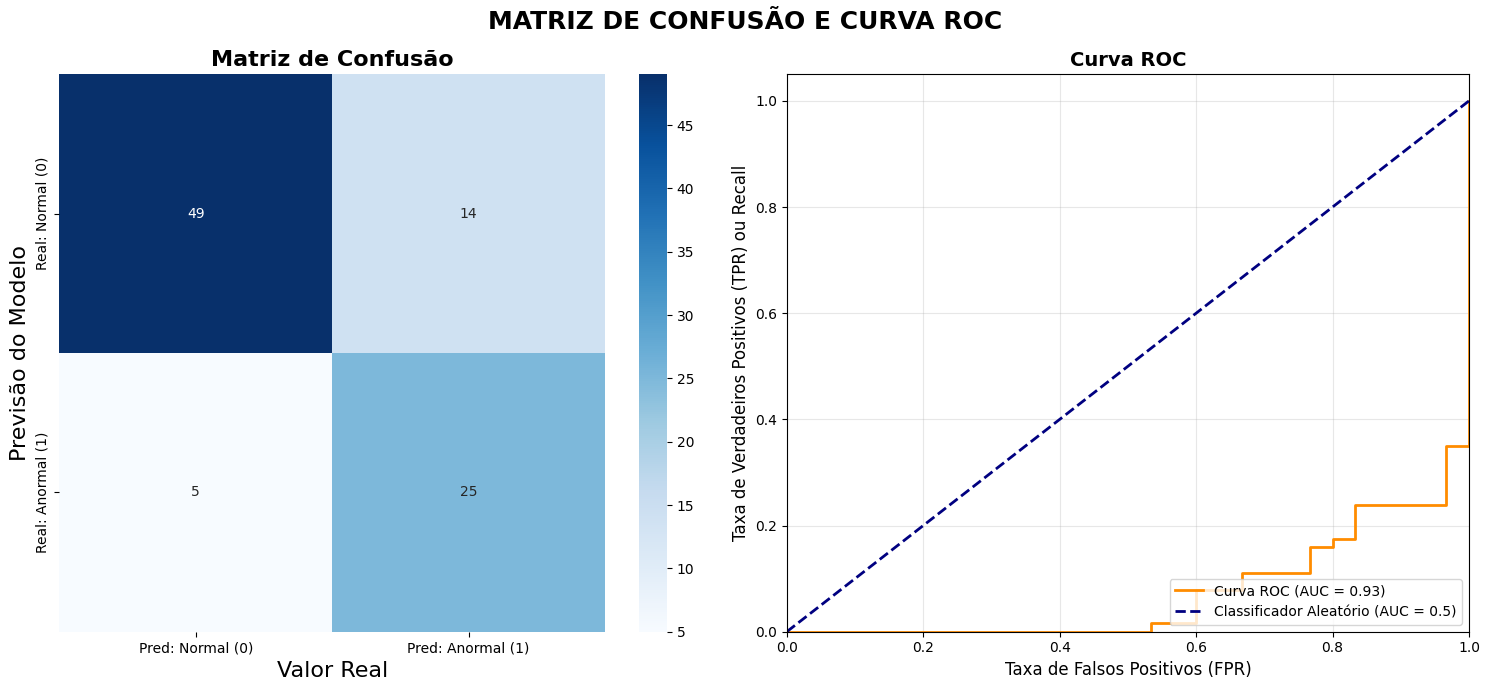

In [30]:
# @title

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

fig.suptitle('MATRIZ DE CONFUSÃO E CURVA ROC',
             fontsize=18, fontweight='bold', y=0.98)

# GRÁFICO 1: Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Normal (0)', 'Pred: Anormal (1)'],
            yticklabels=['Real: Normal (0)', 'Real: Anormal (1)'],
            ax=axes[0])
axes[0].set_title('Matriz de Confusão', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Valor Real', fontsize=16)
axes[0].set_ylabel('Previsão do Modelo', fontsize=16)

# GRÁFICO 2: Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_roc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador Aleatório (AUC = 0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR) ou Recall', fontsize=12)
axes[1].set_title('Curva ROC', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

resultado_html = f"""
<style>
    .result-container {{
        font-family: 'Segoe UI', Arial, sans-serif;
        margin: 20px 0;
    }}
    .header {{
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
        padding: 15px;
        border-radius: 10px;
        text-align: center;
        margin-bottom: 20px;
        font-size: 1.2em;
        font-weight: bold;
    }}
    .card {{
        background: #f8f9fa;
        border-radius: 10px;
        padding: 15px;
        margin-bottom: 15px;
        box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        border-left: 5px solid;
    }}
    .card-acuracia {{ border-left-color: #28a745; }}
    .card-auc {{ border-left-color: #17a2b8; }}
    .card-matrix {{ border-left-color: #6c757d; }}
    .card-title {{
        font-size: 1.1em;
        font-weight: bold;
        margin-bottom: 10px;
    }}
    .card-value {{
        font-size: 1.5em;
        font-weight: bold;
        color: #333;
        margin-bottom: 8px;
    }}
    .card-desc {{
        color: #666;
        font-size: 0.9em;
    }}
    .badge {{
        display: inline-block;
        padding: 3px 8px;
        border-radius: 20px;
        font-size: 0.8em;
        font-weight: bold;
    }}
    .badge-success {{ background: #d4edda; color: #155724; }}
    .badge-danger {{ background: #f8d7da; color: #721c24; }}
    .badge-warning {{ background: #fff3cd; color: #856404; }}
    .badge-info {{ background: #d1ecf1; color: #0c5460; }}
    .matrix-grid {{
        display: grid;
        grid-template-columns: repeat(2, 1fr);
        gap: 15px;
        margin-top: 10px;
    }}
    .matrix-item {{
        background: #f8f9fa;
        padding: 10px;
        border-radius: 8px;
        text-align: center;
    }}
</style>

<div class="result-container">
    <div class="header">
        📊 RESULTADOS DO MODELO RANDOM FOREST - CLASSIFICAÇÃO DA COLUNA VERTEBRAL
    </div>

    <div class="card card-acuracia">
        <div class="card-title">✅ ACURÁCIA</div>
        <div class="card-value">{accuracy:.1%}</div>
        <div class="card-desc">De cada 100 registros, o modelo acerta a previsão para <strong>{accuracy*100:.0f}</strong> deles.</div>
    </div>

    <div class="card card-auc">
        <div class="card-title">📈 AUC-ROC</div>
        <div class="card-value">{auc_roc:.3f}</div>
        <div class="card-desc">Mede a capacidade do modelo de distinguir entre as classes. <br>
        <strong>Interpretação:</strong> 1.0 = perfeito | 0.5 = aleatório | {auc_roc:.3f} = {'Excelente' if auc_roc >= 0.9 else 'Bom' if auc_roc >= 0.8 else 'Moderado'}</div>
    </div>

    <div class="card card-matrix">
        <div class="card-title">📊 MATRIZ DE CONFUSÃO - ANÁLISE DETALHADA</div>
        <div class="matrix-grid">
            <div class="matrix-item">
                <span class="badge badge-success">🟢 VERDADEIROS NEGATIVOS (VN)</span>
                <div style="font-size: 1.8em; font-weight: bold; margin: 8px 0;">{cm[0,0]}</div>
                <div>Normais classificados como <strong>Normais</strong> ✅</div>
            </div>
            <div class="matrix-item">
                <span class="badge badge-success">🔴 VERDADEIROS POSITIVOS (VP)</span>
                <div style="font-size: 1.8em; font-weight: bold; margin: 8px 0;">{cm[1,1]}</div>
                <div>Anormais classificados como <strong>Anormais</strong> ✅</div>
            </div>
            <div class="matrix-item">
                <span class="badge badge-warning">⚠️ FALSOS POSITIVOS (FP)</span>
                <div style="font-size: 1.8em; font-weight: bold; margin: 8px 0;">{cm[0,1]}</div>
                <div>"Falsos Alarmes" - Normal → Anormal ❌</div>
            </div>
            <div class="matrix-item">
                <span class="badge badge-danger">❌ FALSOS NEGATIVOS (FN)</span>
                <div style="font-size: 1.8em; font-weight: bold; margin: 8px 0;">{cm[1,0]}</div>
                <div>"Não Detectados" - Anormal → Normal ❌</div>
            </div>
        </div>
    </div>
</div>
"""

display(HTML(resultado_html))

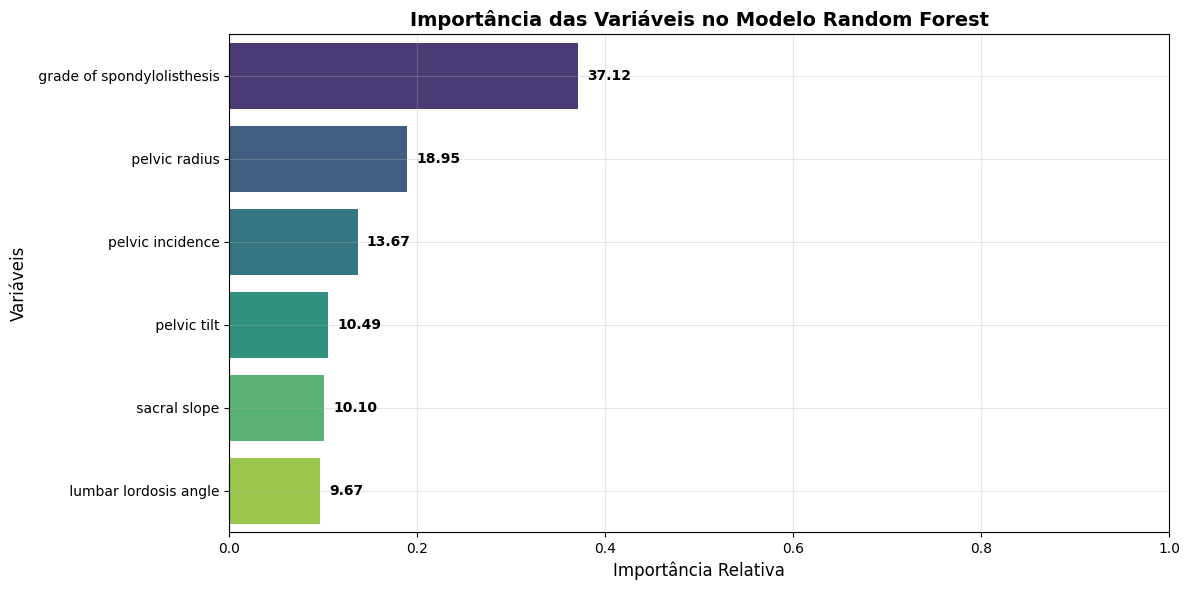

In [31]:
# @title
# Analisar o nivel de importancia dos fatores
importances = model.feature_importances_
feature_names = x.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature',palette='viridis', legend=False)
plt.title('Importância das Variáveis no Modelo Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
for i, v in enumerate(importance_df['importance']):
  plt.text(v + 0.01, i, f'{v*100:.2f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

mais_importante = importance_df.iloc[0]
menos_importante = importance_df.iloc[-1]
total_importancia = importance_df['importance'].sum()

resultado_html = f"""
<style>
    .result-container {{
        font-family: 'Segoe UI', Arial, sans-serif;
        margin: 20px 0;
    }}
    .header {{
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
        padding: 15px;
        border-radius: 10px;
        text-align: center;
        margin: 20px;
        font-size: 1.2em;
        font-weight: bold;
    }}
    .card {{
        background: #f8f9fa;
        border-radius: 10px;
        padding: 15px;
        margin: 20px;
        box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        border-left: 5px solid;
    }}
    .card-acuracia {{ border-left-color: #28a745; }}
    .card-auc {{ border-left-color: #17a2b8; }}
    .card-matrix {{ border-left-color: #6c757d; }}
    .card-title {{
        font-size: 1.1em;
        font-weight: bold;
        margin-bottom: 10px;
    }}
    .card-value {{
        font-size: 1.5em;
        font-weight: bold;
        color: #333;
        margin-bottom: 8px;
    }}
    .card-desc {{
        color: #666;
        font-size: 0.9em;
    }}
    .badge {{
        display: inline-block;
        padding: 3px 8px;
        border-radius: 20px;
        font-size: 0.8em;
        font-weight: bold;
    }}
    .badge-success {{ background: #d4edda; color: #155724; }}
    .badge-danger {{ background: #f8d7da; color: #721c24; }}
    .badge-warning {{ background: #fff3cd; color: #856404; }}
    .badge-info {{ background: #d1ecf1; color: #0c5460; }}
    .matrix-grid {{
        display: flex;
        justify-content: center;
        align-items: center;
        gap: 30px;
        margin-top: 10px;
    }}
    .matrix-item {{
        background: #f8f9fa;
        padding: 10px;
        border-radius: 8px;
        text-align: center;
    }}
</style>

<div class="result-container">
    <div class="header">
        💡 ANÁLISE DAS IMPORTÂNCIAS DAS VARIÁVEIS NO MODELO RANDOM FOREST - CLASSIFICAÇÃO DA COLUNA VERTEBRAL
    </div>

    <div class="card card-acuracia">
        <div class="card-title">🎖️ VARIÁVEL MAIS IMPORTANTE: {mais_importante['feature']}</div>
        <div class="card-value">   - Contribuição: {mais_importante['importance']:.2%}</div>
        <div class="card-desc">    - Significado: Tem o maior poder preditivo para anormalidade na coluna vertebral.</div>
    </div>

    <div class="card card-auc">
        <div class="card-title">📉 VARIÁVEL MENOS IMPORTANTE: {menos_importante['feature']}</div>
        <div class="card-value">   - Contribuição: {menos_importante['importance']:.2%}</div>
        <div class="card-desc">    - Significado: Tem o menor poder preditivo para anormalidade na coluna vertebral. </div>
    </div>

    <div class="card card-matrix">
        <div class="card-title">📈 DISTRIBUIÇÃO DAS IMPORTÂNCIAS:</div>
        <div class="matrix-grid">
            <div class="matrix-item">
                <span class="badge badge-success">✅ SOMA TOTAL</span>
                <div style="font-size: 2.4em; font-weight: bold; margin: 8px 0;">{total_importancia:.4f}</div>
            </div>
            <div class="matrix-item">
                <span class="badge badge-success">✅ MÉDIA</span>
                <div style="font-size: 2.4em; font-weight: bold; margin: 8px 0;">{importance_df['importance'].mean():.4f}</div>
            </div>
            <div class="matrix-item">
                <span class="badge badge-success">✅ DESVIO PADRÃO</span>
                <div style="font-size: 2.4em; font-weight: bold; margin: 8px 0;">{importance_df['importance'].std():.4f}</div>
            </div>
        </div>
    </div>
</div>
"""

display(HTML(resultado_html))



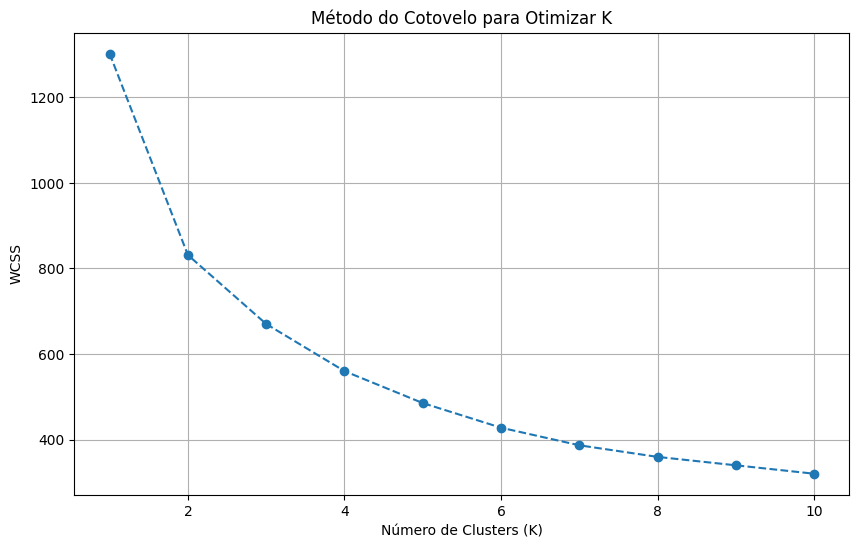

In [32]:
# @title
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_train)
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
  kmeans.fit(x_scaled)
  wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo para Otimizar K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [33]:
# @title
K_IDEAL = 2
kmeans_final = KMeans(n_clusters=K_IDEAL, init='k-means++', max_iter=300, n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(x_scaled)
x_train_df = pd.DataFrame(x_train, columns=x_train.columns)
x_train_df['Cluster'] = cluster_labels


In [34]:
# @title
styled_df = x_train_df.head(10).round(2).copy()

styled = styled_df.style.set_table_styles([
    {'selector': 'thead th',
     'props': [('background-color', '#f0f0f0'),
               ('color', 'black'),
               ('font-weight', 'bold'),
               ('text-align', 'center'),
               ('padding', '10px')]},
    {'selector': 'tbody td',
     'props': [('text-align', 'center'),
               ('padding', '8px'),
               ('border', '1px solid #ddd')]},
    {'selector': 'tbody tr:hover',
     'props': [('background-color', '#f0f0f0')]}
])

styled.set_caption("📊 Primeiras linhas dos dados com rótulo do cluster")
display(styled)

analise_clusters = x_train_df.groupby('Cluster').mean().round(2)
df_medias = analise_clusters.reset_index()

df_medias.columns = ['Cluster', ' Pelvic Incidence', ' Pelvic Tilt', ' Lumbar Lordosis Angle',
                     ' Sacral Slope', ' Pelvic Radius', ' Grade of Spondylolisthesis']

styled = df_medias.style.set_table_styles([
    {'selector': 'thead th',
     'props': [('background-color', '#f0f0f0'),
               ('color', 'black'),
               ('font-weight', 'bold'),
               ('text-align', 'center'),
               ('padding', '10px')]},
    {'selector': 'tbody td',
     'props': [('text-align', 'center'),
               ('padding', '8px'),
               ('border', '1px solid #ddd')]},
    {'selector': 'tbody tr:hover',
     'props': [('background-color', '#f0f0f0')]}
])

styled = styled.set_properties(**{'background-color': 'white'})
styled.set_caption("📊 Características médias de cada Cluster")
display(styled)

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Cluster
267,52.860000,9.410000,46.990000,43.450000,123.090000,1.860000,0
41,46.440000,8.400000,29.040000,38.050000,115.480000,2.050000,0
292,34.760000,2.630000,29.500000,32.120000,127.140000,-0.460000,0
285,67.800000,16.550000,43.260000,51.250000,119.690000,4.870000,0
281,64.260000,14.500000,43.900000,49.760000,115.390000,5.950000,0
0,63.030000,22.550000,39.610000,40.480000,98.670000,-0.250000,0
291,51.080000,14.210000,35.950000,36.870000,115.800000,6.910000,0
105,65.010000,27.600000,50.950000,37.410000,116.580000,7.020000,0
124,74.720000,14.320000,32.500000,60.400000,107.180000,37.020000,1
26,26.150000,10.760000,14.000000,15.390000,125.200000,-10.090000,0


,Cluster,Pelvic Incidence,Pelvic Tilt,Lumbar Lordosis Angle,Sacral Slope,Pelvic Radius,Grade of Spondylolisthesis
0,0,50.150000,13.580000,41.800000,36.570000,119.360000,7.140000
1,1,77.930000,24.060000,69.790000,53.870000,114.260000,57.090000


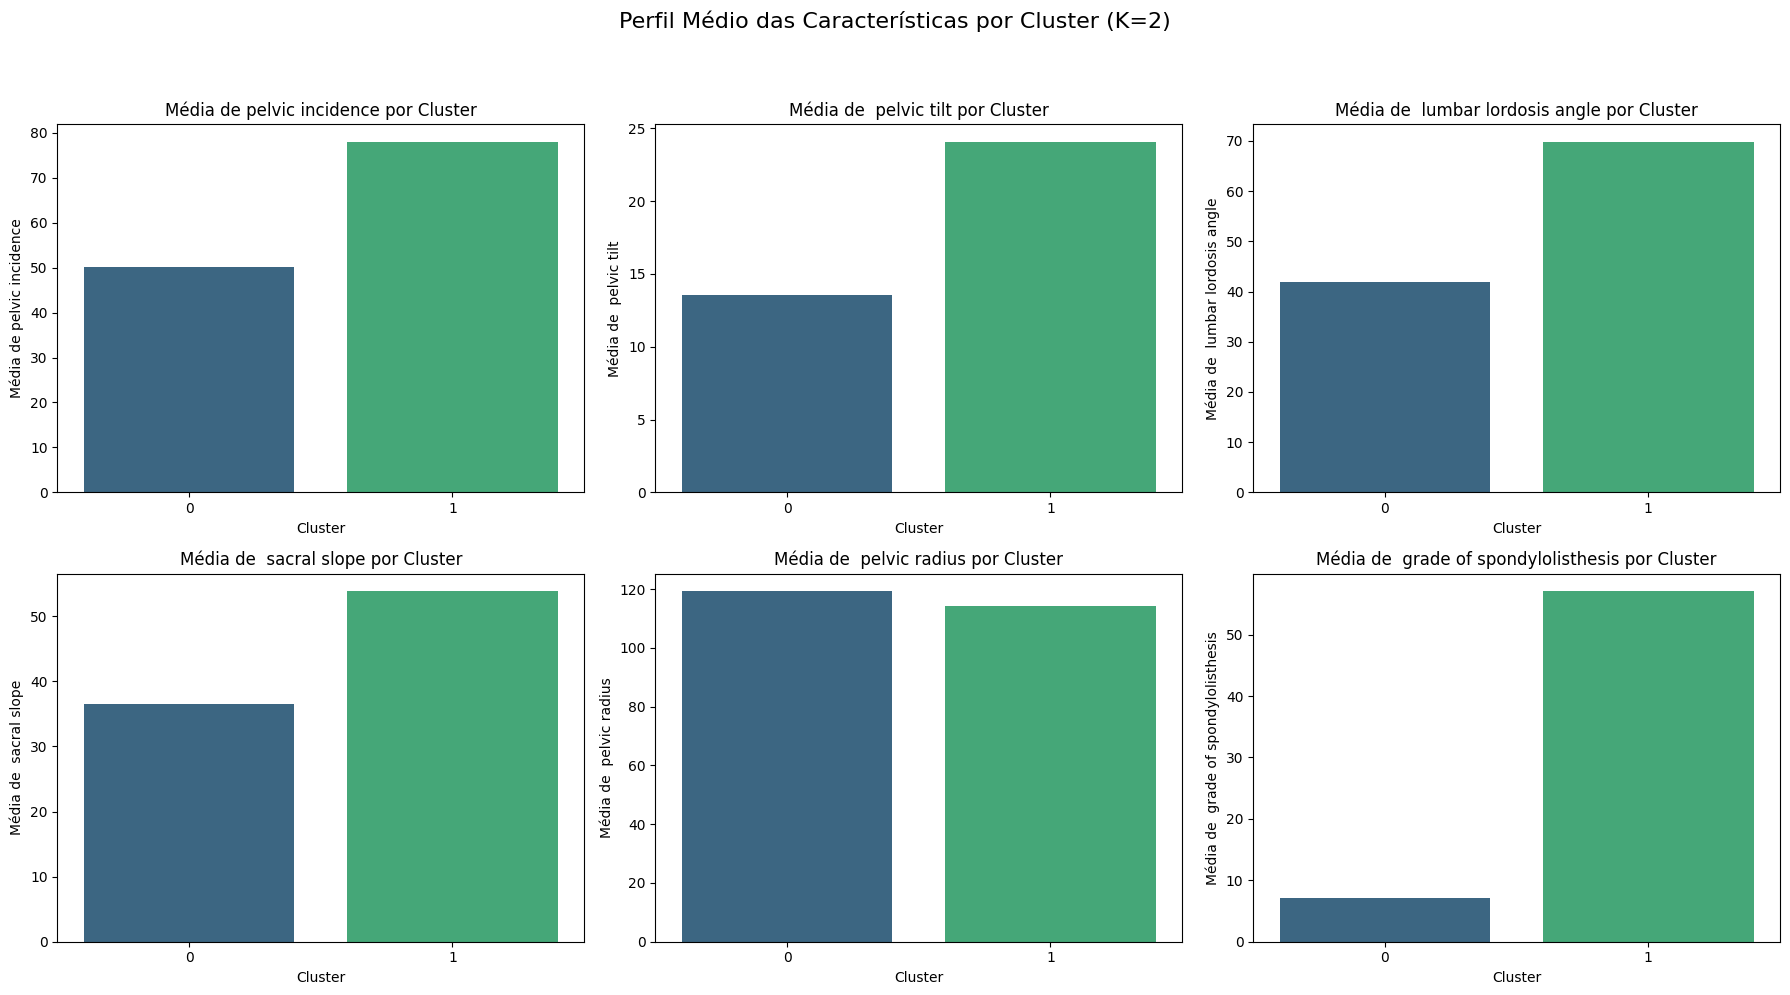


O gráfico de perfis de clusters foi exibido no output acima e salvo no arquivo 'perfis_clusters_k_means.png'.


In [35]:
# @title
df_plot = analise_clusters.reset_index()

features = [col for col in df_plot.columns if col != 'Cluster']
num_features = len(features)
n_cols = 3
n_rows = (num_features + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))
plt.suptitle(f'Perfil Médio das Características por Cluster (K={K_IDEAL})', fontsize=16, y=1.02)


for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.barplot(x='Cluster', y=feature, hue='Cluster', data=df_plot, palette='viridis', legend=False)

    plt.title(f'Média de {feature} por Cluster', fontsize=12)
    plt.ylabel(f'Média de {feature}')
    plt.xlabel('Cluster')


plt.tight_layout(rect=[0, 0.03, 1, 0.98])

plt.savefig('perfis_clusters_k_means.png')

plt.show()

print("\nO gráfico de perfis de clusters foi exibido no output acima e salvo no arquivo 'perfis_clusters_k_means.png'.")

In [36]:
# @title
k_final = K_IDEAL
kmeans_final = KMeans(n_clusters=k_final, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_cluster = kmeans_final.fit_predict(x_scaled)


ari_score = adjusted_rand_score(y_train, y_cluster)
nmi_score = normalized_mutual_info_score(y_train, y_cluster)
contingency_table = pd.crosstab(y_train, y_cluster, rownames=['Real'], colnames=['Cluster'])

In [37]:
# @title
display(Markdown(f"# 📊 Avaliação Externa do K-Means (K={k_final})"))

html_cards = f"""
<div style="display: flex; gap: 20px; margin-bottom: 20px; justify-content: center;">
    <div style="background-color: #f8f9fa; padding: 15px; border-radius: 10px; box-shadow: 2px 2px 5px rgba(0,0,0,0.1); text-align: center; flex:1; max-width: 350px;">
        <h3>✅ Adjusted Rand Index (ARI)</h3>
        <p style="font-size: 32px; color: green;">{ari_score:.4f}</p>
    </div>
    <div style="background-color: #f8f9fa; padding: 15px; border-radius: 10px; box-shadow: 2px 2px 5px rgba(0,0,0,0.1); text-align: center; flex:1; max-width: 350px;">
        <h3>⚠️ Normalized Mutual Information (NMI)</h3>
        <p style="font-size: 32px; color: red;">{nmi_score:.4f}</p>
    </div>
</div>
"""
display(HTML(html_cards))

display(Markdown(f"**Matriz de Contingência (Real vs Cluster)**"))
def estilo_tabela(df):
    # Criar cópia para estilização
    styled = df.style

    # Adicionar bordas
    styled = styled.set_properties(**{
        'border': '2px solid black',
        'font-size': '14px',
        'text-align': 'center',
        'padding': '10px'
    })
    # Destacar totais
    styled = styled.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f8f9fa'),
                                      ('color', 'black'),
                                      ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('min-width', '80px')]}
    ])

    return styled


# Aplicar estilo
styled_table = estilo_tabela(contingency_table)
styled_table



# 📊 Avaliação Externa do K-Means (K=2)

**Matriz de Contingência (Real vs Cluster)**

Cluster,0,1
Real,,
Anormal,66,81
Normal,63,7
